In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dataclasses import dataclass
from dataclasses import replace

%config InlineBackend.figure_format = 'retina'

In [2]:
# utilities
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def row_normalize(matrix, eps=1e-12):
    row_sums = matrix.sum(axis=1, keepdims=True)
    return matrix / (eps + row_sums)


In [39]:
# Experimental function
def build_exp_graph():
    n_node = 11
    community = np.array([0, 0, 0, 0, 0, 
                          1, 1, 1, 1, 1, 1])
    
    node_degree = np.array([4, 3, 3, 4, 4, 
                            4, 3, 3, 4, 4, 4])
    
    edges = [
        # community 1
        (0, 1), (0, 2), (0, 3), (0, 10),
        (1, 0), (1, 3), (1, 4),
        (2, 0), (2, 3), (2, 4),
        (3, 0), (3, 1), (3, 2), (3, 4),
        (4, 1), (4, 2), (4, 3), (4, 5),

        # community 2   
        (5, 4), (5, 6), (5, 8), (5, 9),
        (6, 5), (6, 7), (6, 9),
        (7, 6), (7, 8), (7, 10),
        (8, 5), (8, 7), (8, 9), (8, 10),
        (9, 5), (9, 6), (9, 8), (9, 10),
        (10, 0), (10, 7), (10, 8), (10, 9)
    ]

    adjacency = np.zeros((n_node, n_node))
    for i, j in edges:
        adjacency[i, j] = True

    return adjacency, community, node_degree

def random_walk(adjacency, length, rng, start_node=-1):
    n_nodes = adjacency.shape[0]

    if start_node >= 0:
        current_node = start_node
    else:
        current_node = rng.integers(n_nodes)
    seq = [current_node]

    for _ in range(length - 1):
        neighbors = np.flatnonzero(adjacency[current_node])
        current_node = rng.choice(neighbors)
        seq.append(current_node)
    
    return np.array(seq, dtype=int)

def make_trials(adjacency,
                community,
                rng,
                n_block=10,
                n_tone_per_trial=10):
    '''
    adjacency: np.array [n_node, n_node]
    community: np.array [n_node, 1]
    '''

    n_nodes = adjacency.shape[0]

    # remove possible self-transitions
    adjacency = adjacency.copy()
    np.fill_diagonal(adjacency, 0.0)

    # emulate all posible direct final transitions
    cue, target = np.where(
        ~np.eye(n_nodes, dtype=bool)
    )

    pairs = np.column_stack([cue, target])
    is_legal = adjacency[cue, target] > 0
    is_within = (community[cue] == community[target])

    within_legal = pairs[is_legal & is_within]       # 36
    between_legal = pairs[is_legal & ~is_within]     # 4
    within_illegal = pairs[~is_legal & is_within]    # 14
    between_illegal = pairs[~is_legal & ~is_within]  # 26 out of 56

    # each block - n(legal) == n(illegal)
    n_legal = within_legal.shape[0] + between_legal.shape[0]
    n_between_illegal = n_legal - within_illegal.shape[0]

    # construct each block
    block_tables = []
    for iBlc in range(n_block):
        selected_between_illegal = (
            between_illegal[
                rng.choice(between_illegal.shape[0], 
                           size=n_between_illegal,
                           replace=False)
            ]
        )

        final_pairs = np.vstack(
            [
                within_legal,
                between_legal,
                within_illegal,
                selected_between_illegal
            ]
        )

        # randomize trial order within the block
        final_pairs = final_pairs[rng.permutation(final_pairs.shape[0])]
        final_targets = final_pairs[:, 1]
        final_cue = final_pairs[:, 0]

        # generate first 9 tones & flip
        n_trial_per_block = final_pairs.shape[0]
        prefix = np.empty((n_trial_per_block, n_tone_per_trial-1), dtype=int)
        for iRow in range(n_trial_per_block):
            reversed = random_walk(adjacency, 
                                   length=n_tone_per_trial-1, 
                                   rng=rng, 
                                   start_node=final_cue[iRow])
            prefix[iRow, :] = reversed[::-1]

        sequence = np.column_stack([prefix, final_targets])
        legal = adjacency[final_cue, final_targets] > 0
        within = community[final_cue] == community[final_targets]

        membership_label = np.where(within, 'within', 'between')
        legal_label = np.where(legal, 'legal', 'illegal')
        trial_type = np.char.add(membership_label, '_')
        trial_type = np.char.add(trial_type, legal_label)

        regularity = np.where(within == legal, 'regular', 'irregular')

        block_tbl = pd.DataFrame(
            {
                "block": iBlc,
                "trial_in_block": np.arange(n_trial_per_block),
                "cue": final_cue,
                "target": final_targets,
                'legal': legal,
                "within": within,
                "trial_type": trial_type,
                "regularity": regularity
            }
        )
        block_tbl['sequence'] = list(sequence)
        block_tables.append(block_tbl)
    
    trials_all = pd.concat(block_tables, ignore_index=True)
    n_trial = trials_all.shape[0]
    trials_s1 = trials_all.iloc[: int(n_trial//2), :]
    trials_s2 = trials_all.iloc[int(n_trial//2):, :]


    return trials_s1, trials_s2


In [4]:
# model
@dataclass
class ModelParameters:

    beta: float = 0.06
    reset_current_activity: bool = True

    decision_gain: float = 20.0
    criterion_offset: float = 0.0

    lr: float = 1.0 # exposure learing rate
    lr_test_prefix:float = 1.0 # learning prefix of test sequences
    lr_test_probe:float = 0.1  # learning probe of test sequences

    @property
    def trace_decay(self):
        return np.exp(-self.beta)
    
class HebbianSequenceModel:
    def __init__(self, n_nodes, params):
        self.n_nodes = n_nodes
        self.params = params

        self.W = np.zeros(
            (n_nodes, n_nodes),
            dtype=float
        )

        self.exposure_seq = None

    def update_tone(self, trace, tone_curr, lr):
        tone_curr = int(tone_curr)

        # decay of trace
        trace *= self.params.trace_decay

        # update according to trace strength
        self.W[:,tone_curr] += (lr * trace)

        # activate current tone
        if self.params.reset_current_activity:
            trace[tone_curr] = 1.0
        else:
            trace[tone_curr] += 1.0

        return trace
    
    def learn_exposure(self, sequence):
        sequence = np.asarray(sequence, dtype=int)

        if sequence.ndim != 1:
            raise ValueError("Exposure sequence must be a 1-d array.")
        
        # store exposure sequence
        self.exposure_seq = sequence.copy()

        trace = np.zeros(self.n_nodes, dtype=float)

        trace[sequence[0]] = 1
        for current in sequence[1:]:
            trace = self.update_tone(
                trace=trace, 
                tone_curr=current,
                lr=self.params.lr)
        
        return self
    
    def run_test_phase(self, trials):
        # initialize output
        results = (
            trials
            .sort_values(['block', 'trial_in_block'], kind='stable')
            .reset_index(drop=True)
            .copy()
        )

        sequences = np.stack(
            results['sequence'].to_numpy()
        ).astype(int)

        n_trial, n_tone_per_trial = sequences.shape
        n_prefix = n_tone_per_trial - 1

        # initialize readout (familiarity)
        familiarity = np.empty(n_trial, dtype=float)
        decision_evidence = np.empty(n_trial, dtype=float)
        p_yes = np.empty(n_trial, dtype=float)

        lr_prefix = self.params.lr_test_prefix
        lr_probe  = self.params.lr_test_probe

        for iTrial in range(n_trial):
            seq_cur = sequences[iTrial,:]
            cue = seq_cur[-2]
            target = seq_cur[-1]

            # reset trace at the beginning of each trial
            trace = np.zeros(self.n_nodes, dtype=float)
            trace[seq_cur[0]] = 1.0
            for tone in seq_cur[1:n_prefix]:
                trace = self.update_tone(trace=trace,
                                         tone_curr=tone,
                                         lr = lr_prefix)
        
            # readout before learning the final tone
            ass_matrix = self.association_matrix(normalize=True)
            familiarity[iTrial] = ass_matrix[cue, target]
            uniform_baseline = 1 / (self.n_nodes - 1)
            decision_evidence[iTrial] = (
                familiarity[iTrial] 
                - uniform_baseline 
                - self.params.criterion_offset
             )
            p_yes[iTrial] = sigmoid(self.params.decision_gain * decision_evidence[iTrial])

            # learn the final tone
            trace = self.update_tone(trace=trace,
                                     tone_curr=target,
                                     lr = lr_probe)
            # add model readouts to the trial table
            results['familiarity'] = familiarity
            results['decision_evidence'] = decision_evidence
            results['p_yes'] = p_yes
            
            legal = results['legal'].to_numpy(dtype=bool) 
            results['expected_acc'] = np.where(legal, p_yes, 1-p_yes)
        return results
    
    def association_matrix(self, normalize=True):
        '''
        1. remove diagnal of weight matrix
        2. row normalization
        '''

        matrix = self.W.copy()
        np.fill_diagonal(matrix, 0.0)

        if normalize:
            matrix = row_normalize(matrix)
        
        return matrix
    
    def get_familiarity(self, cue, target, normalize=True):
        matrix = self.association_matrix(normalize=normalize)
        return float(matrix[cue, target])
    
    def decision_evidence(self, cue, target):
        familiarity = self.get_familiarity(cue, 
                                           target, 
                                           normalize=True)
        uniform_baseline = 1.0 / (self.n_nodes - 1)
        evidence = familiarity - uniform_baseline - self.params.criterion_offset

        return evidence
    
    def choice_probability(self, cue, target):
        evidence = self.decision_evidence(cue, target)
        p_yes = sigmoid(evidence * self.params.decision_gain)

        return float(p_yes)
    
    def simulate_choice(self, cue, target, rng):
        p_yes = self.choice_probability(cue, target)
        yes = int(rng.random() < p_yes)
        return{'p_yes': p_yes,
                'yes': yes,
        }
    
    def copy(self):
        copied_model = HebbianSequenceModel(
            n_nodes=self.n_nodes,
            params=self.params,
        )

        copied_model.W = self.W.copy()

        if self.exposure_seq is not None:
            copied_model.exposure_seq = (
                self.exposure_seq.copy()
            )

        return copied_model
    
    def consolidation(self):
        pass

def evaluate_model(model, 
                   trials, 
                   adjacency):
    results = trials.copy()

    cues = results['cue'].to_numpy(dtype=int)
    targets = results['target'].to_numpy(dtype=int)

    # associative familiarity
    ass_matrix = model.association_matrix(normalize=True)
    familiarity = ass_matrix[cues, targets]

    # decision readout
    baseline_uniform = 1 / (model.n_nodes - 1)
    decision_evidence = familiarity - baseline_uniform - model.params.criterion_offset
    p_yes = sigmoid(model.params.decision_gain * decision_evidence)

    # expected accuracy
    expected_acc = np.where(results['legal'].to_numpy(dtype=bool), p_yes, 1-p_yes)
    
    results['familiarity'] = familiarity
    results['decision_evidence'] = decision_evidence
    results['p_yes'] = p_yes
    results['exp_acc'] = expected_acc
    
    return results


In [53]:
def Exp_simulation_day1(n_subj,
                        exposure_length,
                        params=None,
                        seed=1):
    
    if params is None:
        params = ModelParameters()

    adjacency, community, node_degree = build_exp_graph()

    subject_seeds = np.random.SeedSequence(seed).spawn(n_subj)

    all_data = []
    models = []
    trials_s2_all = []
    for iSubj, subj_seed in enumerate(subject_seeds):
        # set seeds for each subject
        exposure_seed, trial_seed = subj_seed.spawn(2)
        exposure_rng = np.random.default_rng(exposure_seed)
        trial_rng = np.random.default_rng(trial_seed)

        exposure_seq = random_walk(adjacency, 
                                   exposure_length, 
                                   exposure_rng)
        
        # train day1 model
        subj_param = replace(params)
        
        mdl_day1 = HebbianSequenceModel(
            n_nodes=adjacency.shape[0],
            params=params
        )
        mdl_day1.learn_exposure(exposure_seq)

        # generate behaviral test trials
        trials_s1, trials_s2 = make_trials(adjacency, 
                                           community, 
                                           trial_rng)
        
        ## frozen model
        # subject_data = evaluate_model(mdl_day1, 
        #                               trials, 
        #                               adjacency)

        # dynamic model that changes with test trials
        subject_data = mdl_day1.run_test_phase(trials=trials_s1)
        subject_data.insert(0, 'subj', iSubj)
        subject_data.insert(1, 'session', 'Day1')

        trials_s2_all.append(trials_s2)

        all_data.append(subject_data)
        models.append(mdl_day1)
    
    all_data = pd.concat(all_data,
                         ignore_index=True)
    
    return all_data, models, trials_s2_all

In [50]:
def Exp_simulation_day2(model_list,
                        trials_s2_list):
    all_data = []
    models_out = []
    for iSubj, model_in in enumerate(model_list):
        model_cur = model_in.copy() # so that model_in are not modified
        trials_s2_cur = trials_s2_list[iSubj]

        # generate behaviral test trials
        subject_data = model_cur.run_test_phase(trials=trials_s2_cur)
        subject_data.insert(0, 'subj', iSubj)
        subject_data.insert(1, 'session', 'Day2')

        all_data.append(subject_data)
        models_out.append(model_cur)
    
    all_data = pd.concat(all_data,
                         ignore_index=True)
    return all_data, models_out

In [70]:
# plot
trial_order = ['within_legal',
               'between_legal',
               'within_illegal',
               'between_illegal']
palette_whole = sns.color_palette('Paired', 12)
my_color = [palette_whole[i] for i in [0, 2, 6, 4]]
my_color_s2 = [palette_whole[i] for i in [1, 3, 7, 5]]

def plot_day1_byType(data, title, my_color):
    avg_within_subj = (
        data.groupby(['subj', 'trial_type'], as_index=False)
        .agg(familiarity = ('familiarity', 'mean'))
    )

    dat4plot = (
        avg_within_subj.groupby('trial_type', as_index=False)
        .agg(mean_dat = ('familiarity', 'mean'),
            sd_dat = ('familiarity', 'std'),
            n_subj = ('familiarity', 'count'))
    )
    dat4plot['se_dat'] = dat4plot['sd_dat'] / np.sqrt(dat4plot['n_subj'])
    dat4plot['trial_type'] = pd.Categorical(
        dat4plot['trial_type'],
        categories=trial_order,
        ordered=True
    )

    dat4plot = dat4plot.sort_values('trial_type').reset_index(drop=True)

    # plot figures
    fig, ax = plt.subplots(figsize=(3, 2.5))
    x=np.arange(len(dat4plot))
    ax.bar(
        x, 
        dat4plot['mean_dat'],
        # yerr=dat4plot['se_dat'],
        width=0.4,
        color=my_color,
        capsize=5,
        error_kw={
            "elinewidth": 1.5,
            "capthick": 1.5
        },
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            "Within-legal",
            "Between-legal",
            "Within-illegal",
            "Between-illegal",
        ],
        rotation=20,
        ha='right'
    )

    ax.set_xlabel("Trial type")
    ax.set_ylabel("Familiarity")
    ax.set_title(title)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return ax

def plot_day2_byType(data_s1, data_s2, measure, ylab, title):
    dat_full = pd.concat([data_s1, data_s2], ignore_index=True)

    avg_within_subj = (
        dat_full
        .groupby(['subj', 'session', 'trial_type'], as_index=False)
        .agg(value = (measure, 'mean'))
    )

    session_order = ['Day1', 'Day2']

    fig, ax = plt.subplots(
        figsize=(5, 3)
    )

    sns.barplot(
        data=avg_within_subj,
        x="trial_type",
        y="value",
        hue="session",
        order=trial_order,
        hue_order=session_order,
        estimator="mean",
        errorbar=None,
        capsize=0.08,
        dodge=True,
        ax=ax
    )

    for container, colors in zip(ax.containers, [my_color, my_color_s2]):
        for bar, color in zip(container, colors):
            bar.set_facecolor(color)
            bar.set_edgecolor('none')
    
    trial_labels = {
        "within_legal": "Within\nlegal",
        "between_legal": "Between\nlegal",
        "within_illegal": "Within\nillegal",
        "between_illegal": "Between\nillegal"
    }

    ax.set_xticklabels(
        [
            trial_labels.get(t, t)
            for t in trial_order
        ]
    )

    ax.set_xlabel("")
    ax.set_ylabel(ylab)
    ax.set_title(title)

    ax.legend(
        title=None,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    sns.despine(ax=ax)

    fig.tight_layout()
    return fig, ax

def summarize_cross_block(data, measure, trial_order):
    # check behavioural change within session 1
    subj_blc_data = (
        data
        .groupby(['subj', 'block', 'trial_type'], 
                as_index=False)
        .agg(value = (measure, 'mean'))
    )

    group_blc_data = (
        subj_blc_data
        .groupby(['block', 'trial_type'],
                as_index=False)
        .agg(mean_val = ('value', 'mean'),
            sd_val = ('value', 'std'),
            n_subj = ('value', 'count'))
    )
    group_blc_data['se_val'] = (
        group_blc_data['sd_val'] 
        / np.sqrt(group_blc_data['n_subj'])
    )
    group_blc_data['trial_type'] = pd.Categorical(
        group_blc_data['trial_type'],
        categories=trial_order,
        ordered=True
    )
    group_blc_data = (
        group_blc_data
        .sort_values(['trial_type', 'block'])
        .reset_index(drop=True)
    )

    return subj_blc_data, group_blc_data

def plot_cross_block(group_data, 
                     ylabel, 
                     title, 
                     colors,
                     ax=None,
                     show_legend=True):
    labels = {
        "within_legal": "within-legal",
        "between_legal": "between-legal",
        "within_illegal": "within-illegal",
        "between_illegal": "between-illegal",
    }

    if ax is None:
        fig, ax = plt.subplots(figsize=(3,2.5))
    else:
        fig = ax.figure
    
    for iType, trial_type in enumerate(trial_order):
        condition_data = (
            group_data[group_data['trial_type'] == trial_type]
            .sort_values('block')
        )

        block_number = condition_data['block'].to_numpy() + 1
        ax.errorbar(
            block_number,
            condition_data["mean_val"],
            yerr=condition_data["se_val"],
            marker="o",
            markersize=5,
            linewidth=1.8,
            capsize=3,
            color=colors[iType],
            label=labels[trial_type],
        )

    ax.set_xticks(
        sorted(group_data['block'].unique() + 1)
    )
    ax.set_xlabel('Test block')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim((0.1, 0.9))

    if show_legend:
        ax.legend(frameon=False, 
                fontsize=6,
                loc="best")
        
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    return ax

### Simulation Start

<Axes: title={'center': 'Day 1 model predictions'}, xlabel='Trial type', ylabel='Familiarity'>

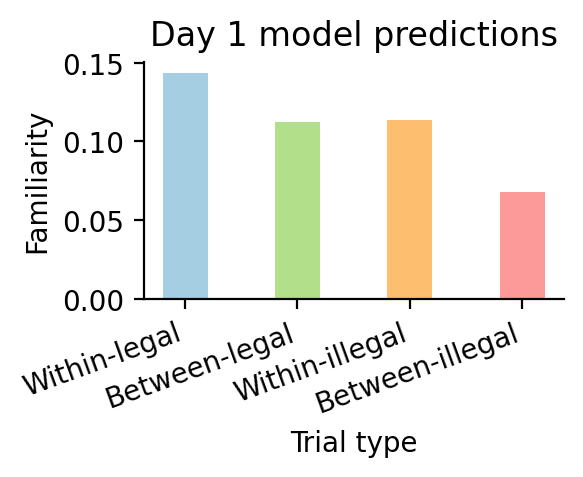

In [54]:
time_ms = 6 * 60 * 1000
iti_ms = 80
tone_ms = 100
exposure_length = time_ms // (iti_ms + tone_ms)

# specify parameters
params_tmp = ModelParameters(
    beta=0.06,
    lr=1.0,
    lr_test_prefix=0.8,
    lr_test_probe=0.1,
    reset_current_activity=True,
    decision_gain=20.0,
    criterion_offset=0.0
)

# run day 1 experiment
day1_data, day1_model, trials_s2_all = Exp_simulation_day1(n_subj=29, 
                                                    exposure_length=exposure_length,
                                                    params=params_tmp)
# trials: tuple, trials[0] - trials in session 1; trials[1] - trials in session 2


plot_day1_byType(day1_data, title="Day 1 model predictions", my_color=my_color)

<Axes: title={'center': 'Dynamic updating model'}, xlabel='Test block', ylabel='p_yes'>

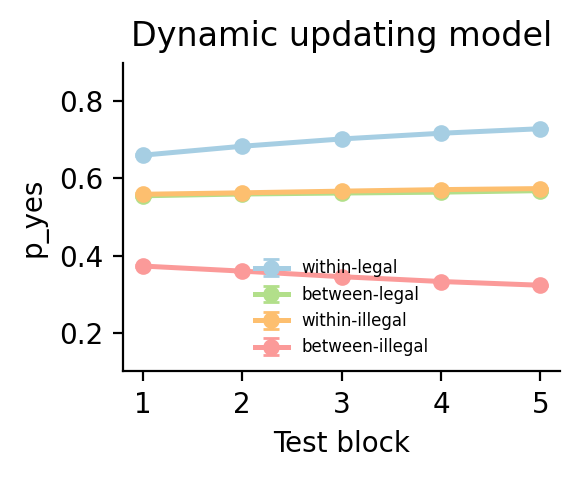

In [48]:
# check behavioural change within session 1
subj_block_p, group_block_p = summarize_cross_block(
    day1_data,
    measure="p_yes",
    trial_order=trial_order
)

plot_cross_block(
    group_block_p,
    ylabel="p_yes",
    title="Dynamic updating model",
    colors=my_color
)


C:\Users\Zhou Xiaoyue\AppData\Local\Temp\ipykernel_33776\935709652.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


(0.2, 0.8)

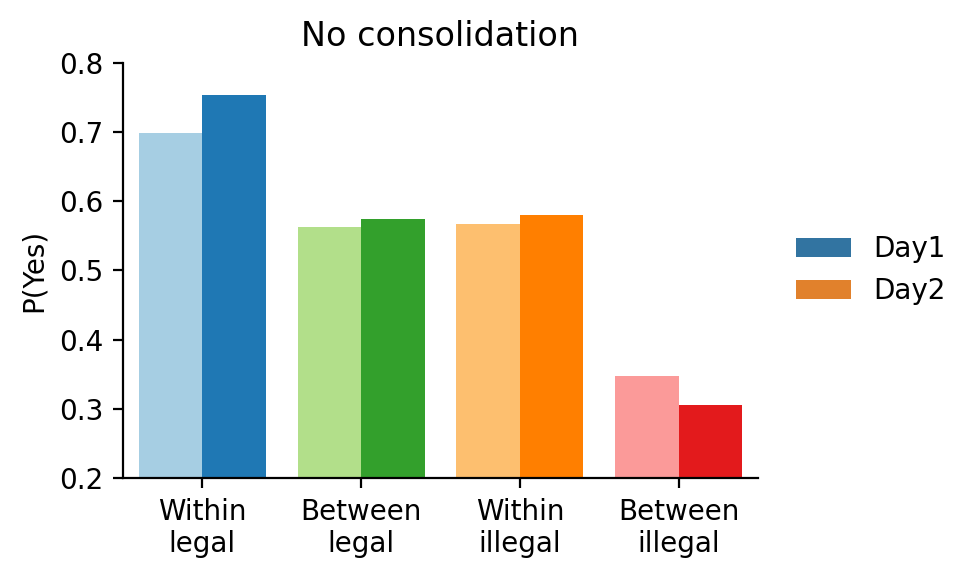

In [76]:
# without consolidation setting - directly session 2
model_list = day1_model # change later, for consolidation
day2_data, model_final = Exp_simulation_day2(model_list,
                                             trials_s2_all)

fig, ax = plot_day2_byType(day1_data, 
                           day2_data, 
                           measure = 'p_yes',
                           ylab = 'P(Yes)',
                           title='No consolidation')
ax.set_ylim([0.2, 0.8])

In [10]:
# 用W画出几个时期represent的网络：
# after exposure
# after session 1
# after consolidation
# after session 2

# 没有consolidation下的session 2 performance?

In [11]:
# frozen-test model
# prefix-learning model
# weak probe-learning model
# full-test-learning model

# check performance change across blocks & trials

In [ ]:
# sweep throu possible beta values (how much to generalize)
betas = [0.02, 0.05, 0.08, 0.11, 0.14, 0.17]
n_col = 3
n_row = int(np.ceil(len(betas) / n_col))

fig, axes = plt.subplots(
    n_row,
    n_col,
    figsize=(10,6),
    sharex = True,
    sharey = True
)
axes = np.asarray(axes).ravel()

for ibeta, beta in enumerate(betas):
    # specify parameters
    params_tmp = ModelParameters(
        beta=beta,
        lr=1.0,
        lr_test_prefix=0.8,
        lr_test_probe=0.1,
        reset_current_activity=True,
        decision_gain=20.0,
        criterion_offset=0.0
    )

    # run day 1 experiment
    day1_data, day1_model = Exp_simulation_day1(n_subj=29, 
                                                exposure_length=exposure_length,
                                                params=params_tmp)
    
    subj_block_p, group_block_p = summarize_cross_block(
        day1_data,
        measure="expected_acc",
        trial_order=trial_order
    )

    plot_cross_block(
        group_block_p,
        ylabel="Expected Accuracy",
        title=f"beta = {beta:.2f}",
        colors=my_color,
        ax = axes[ibeta],
        show_legend=False
    )

# set legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
)

fig.suptitle("Cross-block behavior for different beta values", fontsize=14)
fig.tight_layout(rect=[0, 0, 0.88, 0.95])

plt.show()